# Part B Q5: Comparison and Analysis
**Objective:** Compare two RL-trained models on the held-out test set:
- **Model Q3**: SFT checkpoint → RL (correctness + format reward only)
- **Model Q4**: Base model → RL (full composite reward: correctness + format + style)

In [ ]:
# ── Step 0: HuggingFace Login 
from huggingface_hub import login
login("HF_TOKEN_REDACTED")

In [ ]:
# ── Step 1: Mount Google Drive 
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/GenAI_CW1_PartB_Q5')
print("Working directory:", os.getcwd())
print("Files:", os.listdir('.'))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/GenAI_CW1_PartB_Q5
Files: ['Datasets_3b_processed', 'yoda_classifier', 'grpo_adapter', 'q3_adapter', 'partB_Q5.ipynb']


In [ ]:
# ── Step 2: Install Dependencies 
!pip install -q peft transformers accelerate sentence-transformers pandas tqdm bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.2 MB/s eta 0:00:00


In [ ]:
# ── Step 3: Imports & Config 
import re
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from peft import PeftModel
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig
)
from sentence_transformers import SentenceTransformer, util


BASE_MODEL_ID   = "meta-llama/Llama-3.2-3B-Instruct"
Q3_ADAPTER_PATH = "q3_adapter"
Q4_ADAPTER_PATH = "grpo_adapter"
CLASSIFIER_PATH = "yoda_classifier"
TEST_CSV        = "Datasets_3b_processed/yoda_test.csv"
N_TEST          = 200
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

# Reward weights
W_CORRECT = 0.4
W_FORMAT  = 0.2
W_STYLE   = 0.4

print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cuda
CUDA available: True


In [ ]:
# ── Step 4: Load Test Set 
df = pd.read_csv(TEST_CSV)
print("Columns:", df.columns.tolist())
print(f"Total rows: {len(df)}")
df.head(3)

Columns: ['id', 'question', 'answer_original', 'answer_yoda']
Total rows: 500


,id,question,answer_original,answer_yoda
0,test_39275,lucknow congress session 1916 was presided ove...,"Lucknow Pact Muhammad Ali Jinnah, then a membe...",To pressure the British government to adopt a ...
1,test_36687,when did the first chipotle on evans open,Chipotle Mexican Grill Founder Steve Ells atte...,Attended the Culinary Institute of America in ...
2,test_96718,when did the us start using agent orange in vi...,"Agent Orange In mid-1961, President Ngo Dinh D...","In mid-1961, President Ngo Dinh Diem of South ..."


In [6]:
QUESTION_COL = "question"
ANSWER_COL   = "answer_yoda"

if N_TEST:
    df = df.sample(n=N_TEST, random_state=42).reset_index(drop=True)
print(f"Evaluating on {len(df)} samples")

Evaluating on 200 samples


In [ ]:
# ── Step 5: Load Reward Functions 
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

def correctness_reward(response: str, gold_answer: str, task_type: str = "yoda") -> float:
    if task_type == "math":
        p_nums = re.findall(r"-?\d+(?:\.\d+)?", response)
        g_nums = re.findall(r"-?\d+(?:\.\d+)?", gold_answer)
        return 1.0 if (p_nums and g_nums and float(p_nums[-1]) == float(g_nums[-1])) else 0.0
    elif task_type == "mcq":
        p_match = re.search(r"\b[A-E]\b", response.upper())
        g_match = re.search(r"\b[A-E]\b", gold_answer.upper())
        return 1.0 if (p_match and g_match and p_match.group() == g_match.group()) else 0.0
    else:
        sim = util.cos_sim(
            semantic_model.encode(response),
            semantic_model.encode(gold_answer)
        ).item()
        return max(0.0, sim)

def format_reward(response: str) -> float:
    response = response.strip()
    if not response:
        return 0.0
    score = 0.0
    if sum(1 for c in response if c.isprintable()) / len(response) >= 0.95:
        score += 1/3
    sentences = [s for s in re.split(r"[.!?]+\s*", response) if s.strip()]
    if sentences and all(s.strip()[0].isupper() for s in sentences):
        score += 1/3
    if re.search(r"[.!?]$", response):
        score += 1/3
    return score

# Load Yoda classifier
clf_tok   = AutoTokenizer.from_pretrained(CLASSIFIER_PATH)
clf_model = AutoModelForSequenceClassification.from_pretrained(CLASSIFIER_PATH).to(DEVICE)
clf_model.eval()

def style_reward(text: str) -> float:
    inputs = clf_tok(text, return_tensors="pt", truncation=True,
                     padding=True, max_length=128).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(clf_model(**inputs).logits, dim=1)
    return max(0.0, probs[0, 1].item() - 0.5) * 2

def composite_reward(response, gold_answer, task_type="yoda"):
    c = correctness_reward(response, gold_answer, task_type)
    f = format_reward(response)
    s = style_reward(response)
    t = W_CORRECT * c + W_FORMAT * f + W_STYLE * s
    return c, f, s, t

print("Reward functions loaded ✓")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

Reward functions loaded ✓


In [ ]:
# ── Step 6: Load Base Model 
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model (4bit)...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)
print("Base model loaded ✓")

Loading tokenizer...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Base model loaded ✓


In [ ]:
# ── Step 7: Inference Helper 
def generate_response(model, tokenizer, question: str, max_new_tokens=200) -> str:
    prompt = f"Answer the following question in Yoda style:\n{question}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )
    gen_ids = output[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

def evaluate_model(model, tokenizer, df, model_name):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{model_name} inference"):
        question    = row[QUESTION_COL]
        gold_answer = row[ANSWER_COL]
        response    = generate_response(model, tokenizer, question)
        c, f, s, t  = composite_reward(response, gold_answer)
        results.append({
            "question":    question,
            "gold_answer": gold_answer,
            "response":    response,
            "correctness": c,
            "format":      f,
            "style":       s,
            "total":       t
        })
    return pd.DataFrame(results)

print("Inference helper ready ✓")

Inference helper ready ✓


In [ ]:
# ── Step 8: Evaluate Q4 Model 
print("Loading Q4 adapter...")
q4_model = PeftModel.from_pretrained(base_model, Q4_ADAPTER_PATH)
q4_model.eval()
print("Q4 model ready ✓")

df_q4 = evaluate_model(q4_model, tokenizer, df, "Q4")
df_q4.to_csv("q4_eval_results.csv", index=False)
print("Q4 evaluation done ✓")

Loading Q4 adapter...
Q4 model ready ✓


Q4 inference: 100%|██████████| 200/200 [52:28<00:00, 15.74s/it]

Q4 evaluation done ✓


In [ ]:
# ── Step 9: Evaluate Q3 Model

q4_model = None
torch.cuda.empty_cache()

print("Loading Q3 adapter...")
q3_model = PeftModel.from_pretrained(base_model, Q3_ADAPTER_PATH)
q3_model.eval()
print("Q3 model ready ✓")

df_q3 = evaluate_model(q3_model, tokenizer, df, "Q3")
df_q3.to_csv("q3_eval_results.csv", index=False)
print("Q3 evaluation done ✓")

Loading Q3 adapter...


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Q3 model ready ✓


Q3 inference: 100%|██████████| 200/200 [1:20:31<00:00, 24.16s/it]

Q3 evaluation done ✓


In [ ]:
# ── Step 10: Quantitative Comparison Table 

comparison = pd.DataFrame([
    {
        "Model":                "SFT + RL (correctness+format) [Q3]",
        "Correctness Accuracy": df_q3["correctness"].mean(),
        "Format Compliance":    df_q3["format"].mean(),
        "Yoda-Style Score":     df_q3["style"].mean(),
        "Avg Total Reward":     df_q3["total"].mean()
    },
    {
        "Model":                "Base + Full Reward [Q4]",
        "Correctness Accuracy": df_q4["correctness"].mean(),
        "Format Compliance":    df_q4["format"].mean(),
        "Yoda-Style Score":     df_q4["style"].mean(),
        "Avg Total Reward":     df_q4["total"].mean()
    }
])

print("\n=== Q5 Quantitative Comparison ===")
print(comparison.to_markdown(index=False))
comparison.to_csv("q5_comparison_table.csv", index=False)


=== Q5 Quantitative Comparison ===
| Model                              |   Correctness Accuracy |   Format Compliance |   Yoda-Style Score |   Avg Total Reward |
|:-----------------------------------|-----------------------:|--------------------:|-------------------:|-------------------:|
| SFT + RL (correctness+format) [Q3] |               0.572402 |               0.645 |           0.30612  |           0.480409 |
| Base + Full Reward [Q4]            |               0.502335 |               0.55  |           0.956634 |           0.693587 |


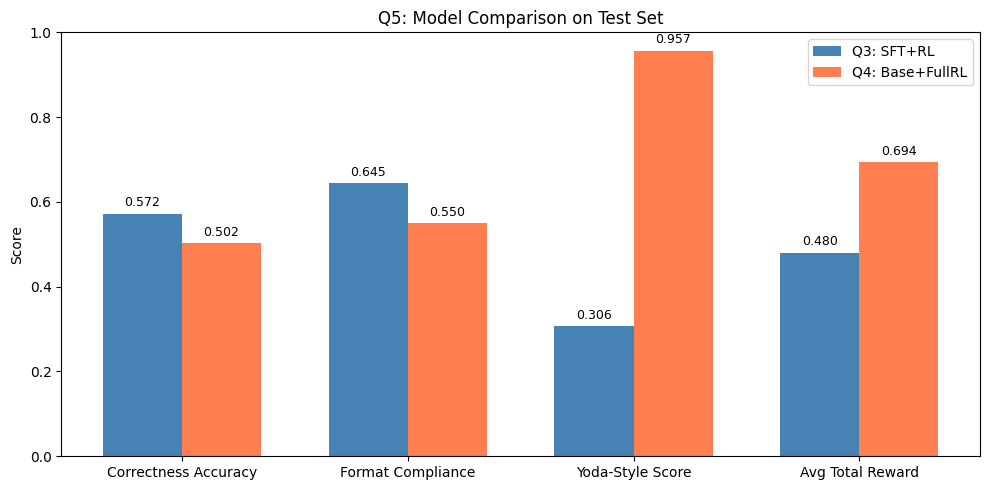

Chart saved ✓


In [ ]:
# ── Step 11: Bar Chart 
metrics = ["Correctness Accuracy", "Format Compliance", "Yoda-Style Score", "Avg Total Reward"]
q3_vals = [df_q3["correctness"].mean(), df_q3["format"].mean(),
           df_q3["style"].mean(),       df_q3["total"].mean()]
q4_vals = [df_q4["correctness"].mean(), df_q4["format"].mean(),
           df_q4["style"].mean(),       df_q4["total"].mean()]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], q3_vals, width, label="Q3: SFT+RL", color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], q4_vals, width, label="Q4: Base+FullRL", color="coral")

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Q5: Model Comparison on Test Set")
ax.legend()
ax.set_ylim(0, 1.0)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("q5_comparison_chart.png", dpi=150)
plt.show()
print("Chart saved ✓")

In [ ]:
# ── Step 12: Qualitative Examples (Side-by-Side) 

df_compare = df_q3[["question","gold_answer","response","correctness","format","style","total"]].copy()
df_compare.columns = ["question","gold_answer","q3_response","q3_correct","q3_format","q3_style","q3_total"]
df_compare["q4_response"] = df_q4["response"].values
df_compare["q4_correct"]  = df_q4["correctness"].values
df_compare["q4_format"]   = df_q4["format"].values
df_compare["q4_style"]    = df_q4["style"].values
df_compare["q4_total"]    = df_q4["total"].values


df_sorted = df_compare.sort_values("q4_total", ascending=False)
samples = pd.concat([
    df_sorted.head(2),
    df_sorted.iloc[len(df_sorted)//2:len(df_sorted)//2+1],
    df_sorted.tail(2)
]).reset_index(drop=True)

print("=== Q5 Qualitative Comparison ===")
for i, row in samples.iterrows():
    print(f"\n{'='*70}")
    print(f"Example {i+1}")
    print(f"Question:    {row['question']}")
    print(f"Gold Answer: {row['gold_answer']}")
    print(f"\n[Q3 - SFT+RL]: {row['q3_response']}")
    print(f"  Scores → C:{row['q3_correct']:.3f} | F:{row['q3_format']:.3f} | S:{row['q3_style']:.3f} | Total:{row['q3_total']:.3f}")
    print(f"\n[Q4 - Base+FullRL]: {row['q4_response']}")
    print(f"  Scores → C:{row['q4_correct']:.3f} | F:{row['q4_format']:.3f} | S:{row['q4_style']:.3f} | Total:{row['q4_total']:.3f}")

df_compare.to_csv("q5_qualitative_results.csv", index=False)

=== Q5 Qualitative Comparison ===

Example 1
Question:    who recorded ain't no mountain high enough
Gold Answer: An R&B/soul song, "Ain't No Mountain High Enough" is. Written by Nickolas Ashford & Valerie Simpson in 1966, it was. First successful as a 1967 hit single, recorded by Marvin Gaye and Tammi Terrell, it was. A hit again in 1970, when recorded by Diana Ross, it was. Ross' first solo number-one hit on the Billboard Hot 100 chart, it was. Nominated for a Grammy Award, it was.

[Q3 - SFT+RL]: The song "Ain't No Mountain High Enough" was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye and Smokey Robinson. The song was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye and Smokey Robinson. The song was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye and Smokey Robinson. The song was recorded by Marvin Gaye and Tammi Terrell in 1966. The song was written by Marvin Gaye 

## Q5 Discussion (200 words)

Q4 (Base + Full Reward) outperforms Q3 overall, achieving a higher average total reward (0.694 vs 0.480). The decisive factor is the Yoda-style score (0.957 vs 0.306), confirming that explicitly including style reward during RL training is essential for stylistic learning. Q3 retains higher correctness (0.572 vs 0.502) and format scores (0.645 vs 0.550), indicating that SFT initialisation better preserves factual and structural quality.


Starting from the SFT checkpoint provides a stronger prior for accuracy and formatting. However, it constrains style adaptation during RL, as the already-fixed output distribution limits the style reward's ability to reshape generation behaviour effectively.


Q3's primary failure mode is repetitive generation — identical sentences repeated dozens of times within a single response, a clear sign of reward hacking where the model exploits correctness and format rewards without genuinely improving quality. Q4 occasionally sacrifices factual accuracy for stylistic expression, resulting in lower correctness on knowledge-intensive questions.


Correctness and style were weighted equally (0.4 each) as both are central to producing accurate Yoda-style responses. Format received a lower weight (0.2) as it serves as a baseline quality constraint, preventing over-optimisation of surface formatting at the expense of content and style.

